In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
sns.set_theme(style="white")
work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.evaluators import CompareModels, ModelEvaluator
from scripts.plot_function import *
plot_path = 'M:\\1confiProj\\Analysis\\output\\'

device is : cpu


In [75]:
### prepare model simulation data
m_label = 'with_dn'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim = pd.concat(df_sim_lst, ignore_index=True)

### prepare behavior data
df_beh = ev.dh.get_allsub_beh_data()

Model 2 subjects:   0%|          | 0/8 [00:00<?, ?subject/s]


 ------- Start Aggregating for Subject 2 ---------- 


Model 2 subjects:  12%|█▎        | 1/8 [00:00<00:02,  2.40subject/s]


 ------- Start Aggregating for Subject 3 ---------- 


Model 2 subjects:  25%|██▌       | 2/8 [00:00<00:02,  2.83subject/s]

...

Model 2 subjects:  75%|███████▌  | 6/8 [00:02<00:00,  2.98subject/s]


 ------- Start Aggregating for Subject 20 ---------- 


Model 2 subjects:  88%|████████▊ | 7/8 [00:02<00:00,  3.13subject/s]


 ------- Start Aggregating for Subject 25 ---------- 


Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  3.03subject/s]


# Behavioural Analysis

## 1. Localization raw data

### Sub-level

In [76]:
def add_counts(df, ax, xloc, yloc,color):
    counts = df.groupby('AudLoc').size()
    for audloc, count in counts.items():
        ax.annotate(f'{count}', xy=(audloc+xloc, yloc), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, color=color)
def add_avg_line(df, ax,color, resp_var='RespLoc'):
    avg_response = df.groupby('AudLoc')[resp_var].mean().reset_index()
    ax.plot(avg_response['AudLoc'], avg_response[resp_var], color=color, linewidth=1,alpha=0.7)

In [77]:
def plot_raw_rep_sub(df, sub_id, rel, ax, visloc, palette, resp_var='RespLoc', modality='A', legend=True, offset = 1, avg_line=False, n_case = True):
    df_plot = df[(df['Modality'] == modality)&(df.VisRelLabel==rel)&(df.sub_id == sub_id)]

    # Congruent condition
    df_same = df_plot[df_plot.AudLoc == df_plot.VisLoc]
    ax.plot(df_same['AudLoc'], df_same[resp_var], 'o', color='red', markersize=2, alpha=0.7, label='Congruent')

    # Congruent condition
    df_vis = df_plot[df_plot.VisLoc == visloc]
    ax.plot(df_vis['AudLoc'] + offset, df_vis[resp_var], 'o', color=palette[visloc], markersize=2, alpha=0.7, label=f'Visual Stimulus Location = {visloc}')
    
    if avg_line:
        add_avg_line(df=df_same, ax=ax, color = 'red', resp_var=resp_var)
        add_avg_line(df=df_vis, ax=ax, color = palette[visloc], resp_var=resp_var)
    if n_case:
        add_counts(df=df_same, ax=ax, xloc=0, yloc=15.5, color='red')
        add_counts(df=df_vis, ax=ax, xloc=0, yloc=14, color=palette[visloc])
    
    if resp_var=='RespLoc':
        # add the reference lines
        ax.plot([-10, 10], [-10, 10], '--', color='red', linewidth=1, alpha=0.6, zorder=0)
        ax.hlines(y=visloc, xmin=-10, xmax=10, color=palette[visloc], linestyle='--', linewidth=1)

    if visloc!=0:
        df_vism = df_plot[df_plot.VisLoc == -visloc]
        ax.plot(df_vism['AudLoc'] - offset, df_vism[resp_var], 'o', color=palette[-visloc], markersize=2, alpha=0.7, label=f'Visual Stimulus Location = -{visloc}')
        if resp_var=='RespLoc':
            ax.hlines(y=-visloc, xmin=-10, xmax=10, color=palette[-visloc], linestyle='--', linewidth=1)

        if avg_line:
            add_avg_line(df=df_vism, ax=ax, color=palette[-visloc], resp_var=resp_var)
        if n_case:
            add_counts(df=df_vism, ax=ax, xloc=0, yloc=-16, color=palette[-visloc])

    if legend:
        ax.legend(frameon=False, ncol=2,fontsize=fontsize-2, loc='lower center', bbox_to_anchor=(0.9, -0.55))

    clean_axs(ax)

    ax.set_xlabel('Sound Location ($^\\circ$)', fontsize=fontsize)
    ## Autoscale first
    ax.xaxis.set_major_locator(MultipleLocator(5))
    if resp_var=='RespLoc':
        ax.set_aspect('equal', adjustable='box')
        ax.yaxis.set_major_locator(MultipleLocator(5))
        
    #ax.set_ylabel('Response Location', fontsize=12)

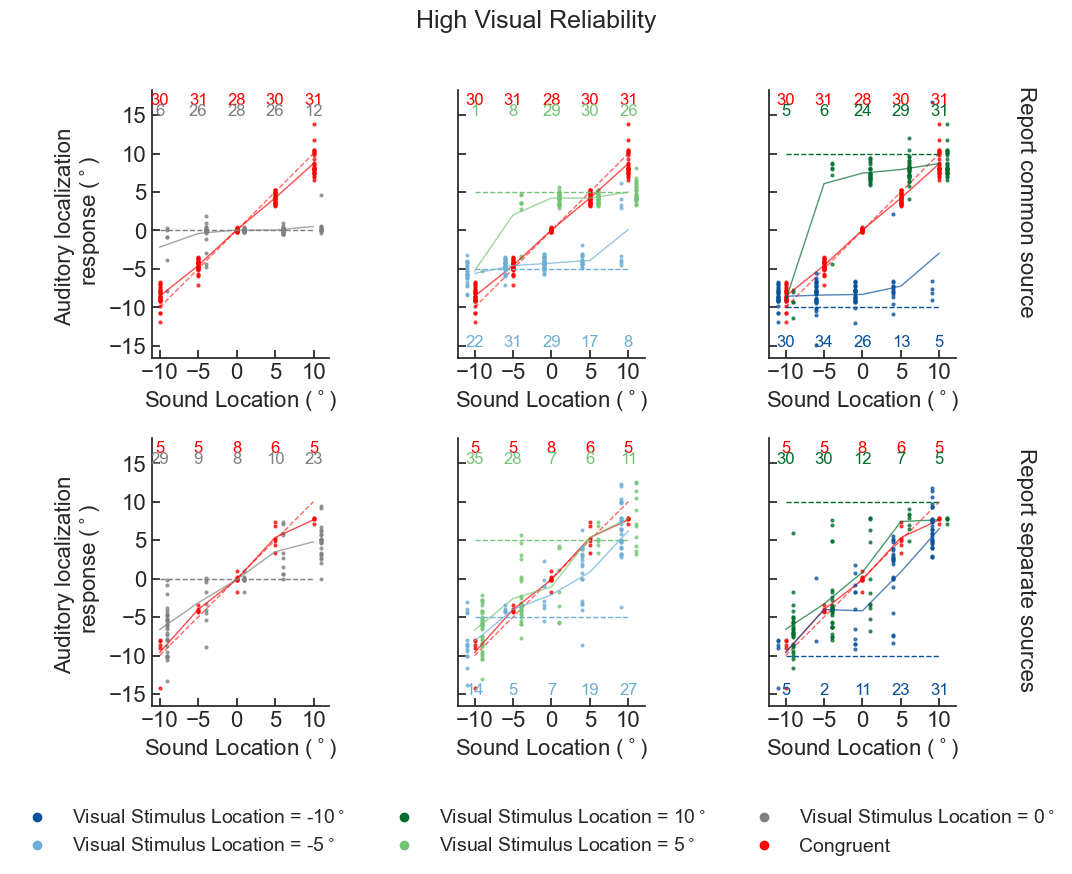

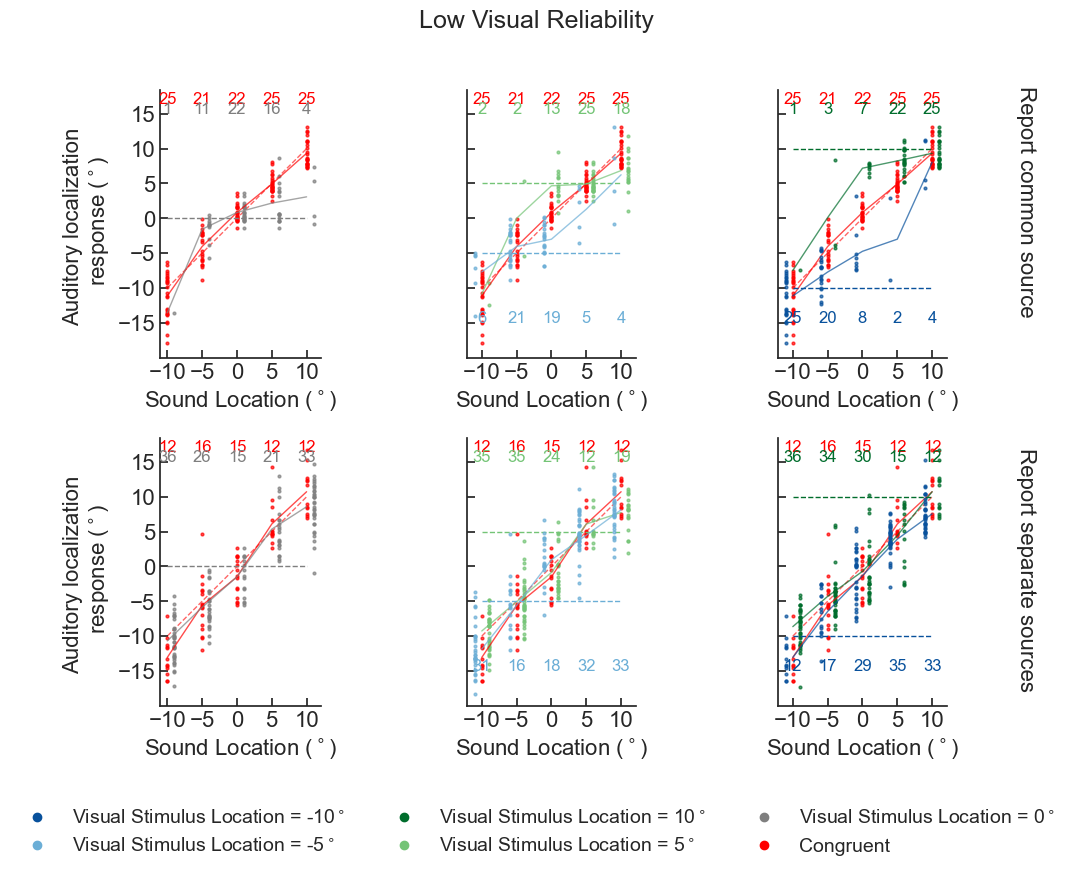

In [78]:
sub_id= 11

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace': 0.01, 'hspace': 0.3}
    )
    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_sub(
                df=df_beh.loc[df_beh.Sources==sources], 
                sub_id=sub_id, 
                rel=vrel, 
                ax=axs[row,col], 
                visloc=visloc, 
                legend=False, 
                avg_line=True,
                palette=palette_vloc
            )

    legend_elements = [
        Line2D(
            [0], [0],
            linestyle='None',
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    axs[1,0].set_ylabel('Auditory localization \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Auditory localization \n response ($^\\circ$)', fontsize=fontsize)
    legend_elements.append(
        Line2D(
            [0], [0],
            linestyle='None',
            marker='o',
            markersize=6,
            markerfacecolor='red',
            markeredgecolor='red',
            label="Congruent",
        )
    )

    fig.legend(
        handles=legend_elements,
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)
    fig.text(
        0.9, 0.74, 'Report common source',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.9, 0.28, 'Report separate sources',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    plt.savefig(os.path.join(plot_path, 'sub_select',  f'sub_{sub_id}_raw_rep_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

### All sub (mean)

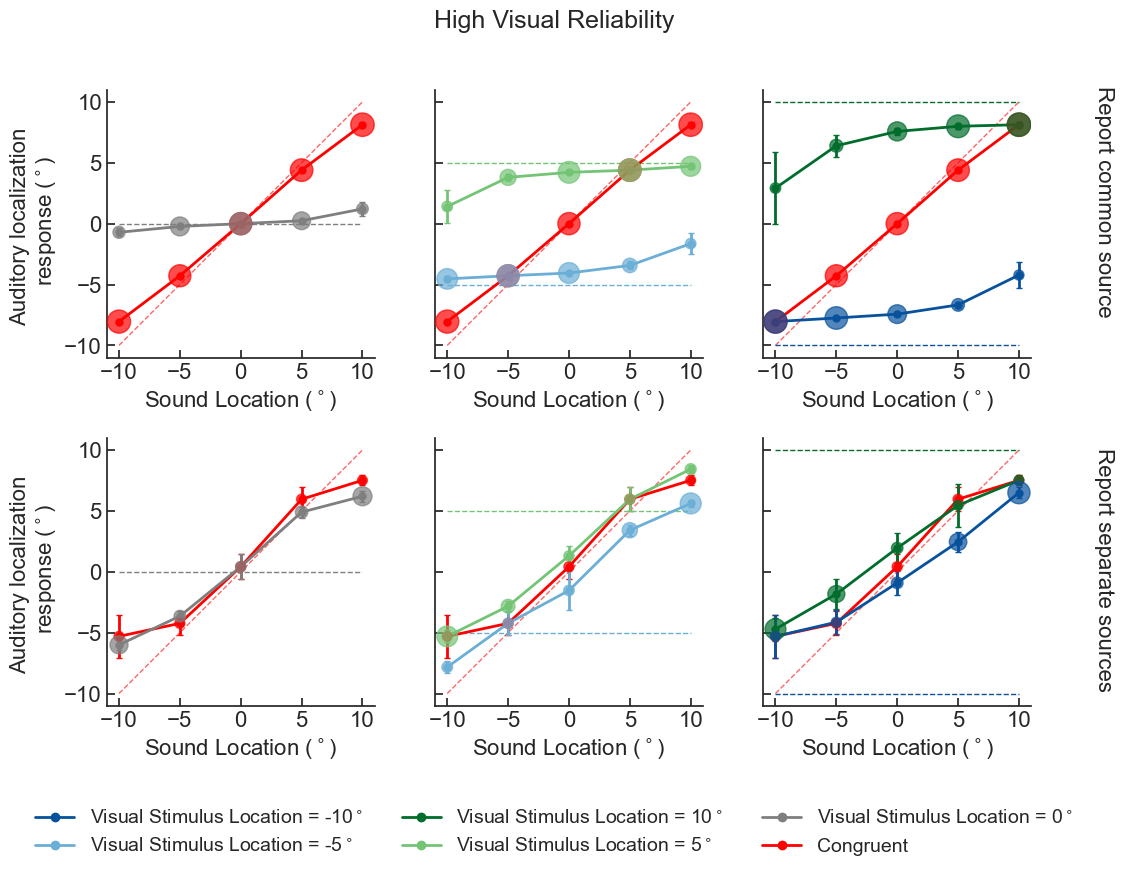

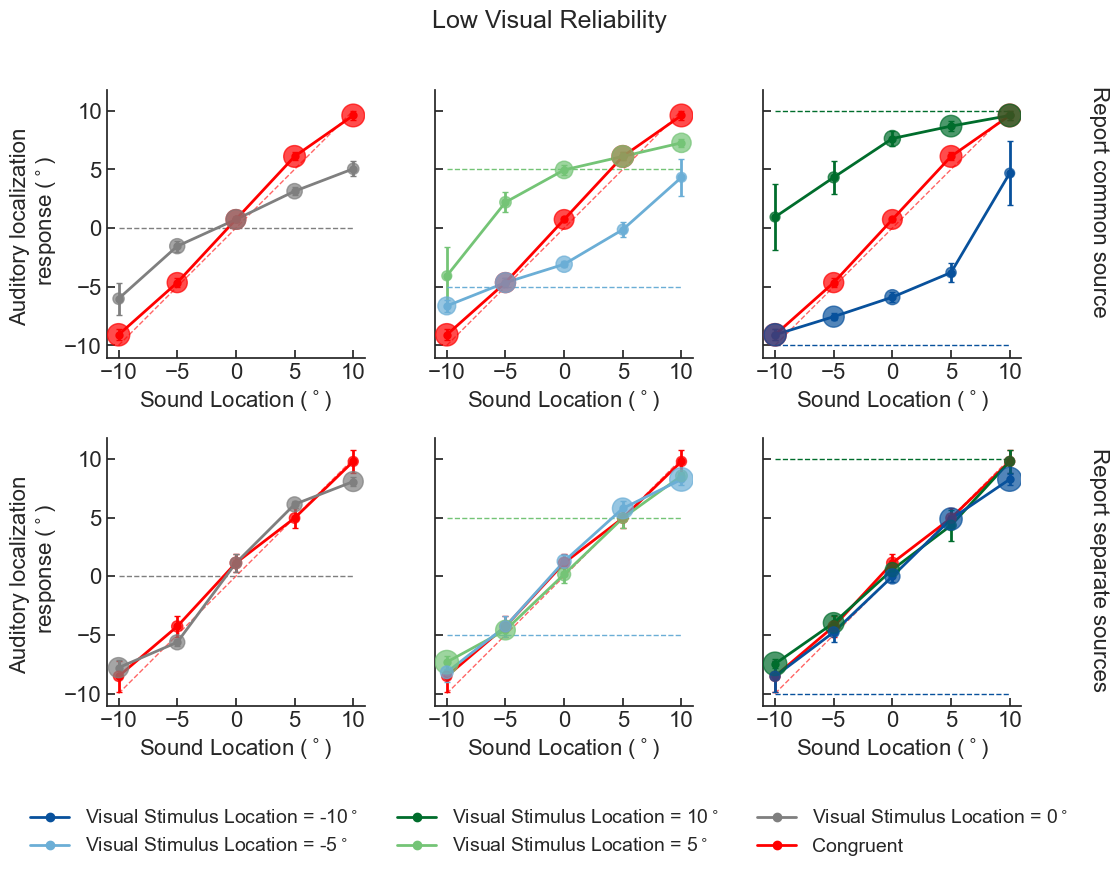

In [79]:
# compute the cross-condition counts min and max for scaling function
global_min, global_max = get_global_min_max(df=df_beh, groupvar = ["AudLoc", "VisLoc"])

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace':0.2, 'hspace': 0.3}
    )

    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_all(
                df=df_beh.loc[df_beh.Sources == sources],
                rel=vrel,
                ax=axs[row, col],
                visloc=visloc,
                #resp_var='CISize',
                legend=False,
                palette=palette_vloc,
                scale = True,
                global_min=global_min,
                global_max = global_max,
                power=2
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color=palette_vloc[vloc],
            lw=2,
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    legend_elements.append(
                       Line2D(
                        [0], [0],
                        color='red',
                        lw=2,
                        marker='o',
                        markersize=6,
                        markerfacecolor='red',
                        markeredgecolor='red',
                        label="Congruent",
                    ))
    fig.legend(
        handles=legend_elements,
        title='',
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)

    axs[1,0].set_ylabel('Auditory localization \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Auditory localization \n response ($^\\circ$)', fontsize=fontsize)

    fig.text(
        0.95, 0.74, 'Report common source',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.95, 0.28, 'Report separate sources',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )
    #fig.supylabel('Auditory Response Location', fontsize=fontsize)
    plt.savefig(os.path.join(plot_path,'Raw_loc', f'Allsub_raw_re_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

In [80]:
df_beh

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,...,mean,bias,flipBias,abs_delta_VA,bias_abs,bias_abs_rel,bias_rel,bias_abs_zscore,bias_zscore,CISize_zscore
0,5.0,-10.0,1.0,1.0,-4.93,4.69,1.0,20.0,2,-15.0,...,5.146216,-10.076216,10.076216,15.0,-9.93,0.662000,0.671748,-1.798937,-1.986749,-0.331626
1,-10.0,10.0,1.0,1.0,4.93,4.46,2.0,41.0,2,20.0,...,-8.312162,13.242162,13.242162,20.0,14.93,0.746500,0.662108,2.319995,2.235716,-0.460572
2,-5.0,-10.0,1.0,1.0,-5.94,5.56,1.0,39.0,2,-5.0,...,-4.934054,-1.005946,1.005946,5.0,-0.94,0.188000,0.201189,-0.309428,-0.344315,0.156129
3,-5.0,5.0,1.0,1.0,4.38,2.01,1.0,78.0,2,10.0,...,-4.934054,9.314054,9.314054,10.0,9.38,0.938000,0.931405,1.400442,1.524418,-1.834135
4,-5.0,-5.0,1.0,1.0,-3.82,2.91,1.0,88.0,2,0.0,...,-4.934054,1.114054,1.114054,0.0,1.18,inf,inf,0.041825,0.039572,-1.329561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19427,5.0,-10.0,2.0,0.0,-6.94,9.95,2.0,84.0,25,-15.0,...,-7.918333,0.978333,-0.978333,15.0,3.06,-0.204000,-0.065222,1.293300,0.529720,0.045977
19428,-10.0,5.0,2.0,0.0,5.83,8.22,2.0,100.0,25,15.0,...,5.925833,-0.095833,-0.095833,15.0,0.83,0.055333,-0.006389,0.273393,-0.135190,-0.396073
19429,10.0,5.0,2.0,0.0,5.94,11.75,1.0,100.0,25,-5.0,...,5.925833,0.014167,-0.014167,5.0,0.94,-0.188000,-0.002833,0.323702,-0.067100,0.505913
19430,-5.0,-5.0,2.0,0.0,-5.60,11.77,1.0,100.0,25,0.0,...,-5.005833,-0.594167,-0.594167,0.0,-0.60,-inf,-inf,-0.380628,-0.443658,0.511023


### beh variability as a function of spatial disparity

C:\Users\wenlou\AppData\Local\Temp\ipykernel_10608\1729424961.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


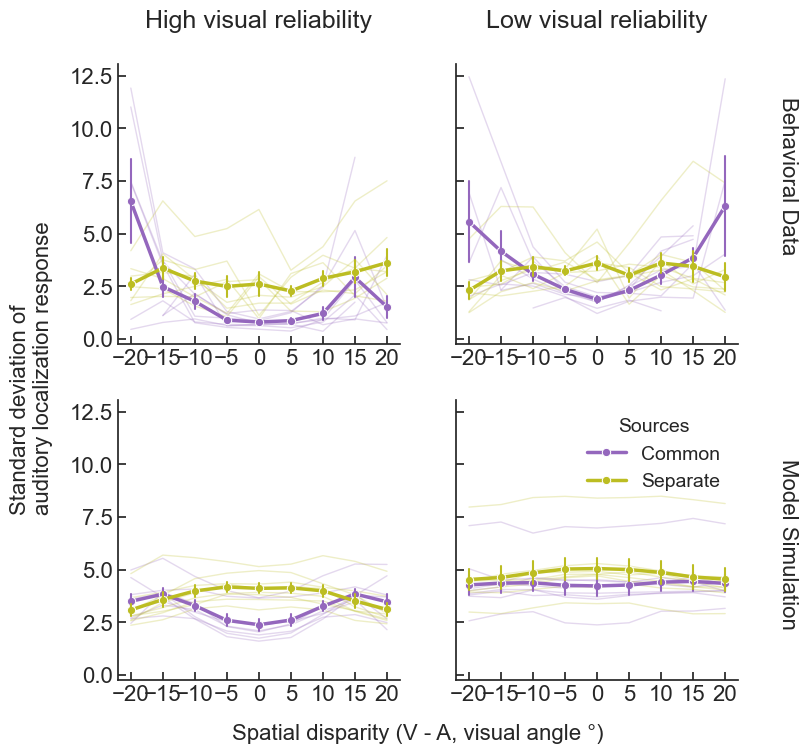

In [81]:
def get_summary_std(df):
    df_plot = df[df.Modality == "A"]

    # 1. SD for each auditory location within each subject
    summary_aud = (
        df_plot
        .groupby(["delta_VA", "VisRelLabel", "Sources", "AudLoc", "sub_id"])
        .agg(std=("RespLoc", "std"))
        .reset_index()
    )

    # 2. Average SD across auditory locations for each subject
    summary_sub = (
        summary_aud
        .groupby(["delta_VA", "VisRelLabel", "Sources", "sub_id"], as_index=False)
        .agg(mean_std=("std", "mean"))
    )
    return summary_sub

df_sum_beh = get_summary_std(df_beh)
df_sum_sim = get_summary_std(df_sim)

fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=True, gridspec_kw={'wspace':0.2, 'hspace':0.2})

for row, dat in enumerate([df_sum_beh, df_sum_sim]):
    for col, vrel in enumerate(["High", "Low"]):

        data = dat.query("VisRelLabel == @vrel")

        # Subject-level trajectories
        sns.lineplot(
            data=data,
            x="delta_VA",
            y="mean_std",
            hue="Sources",
            units="sub_id",
            estimator=None,
            palette = ["tab:purple", "tab:olive"],
            alpha=0.25,
            lw=1,
            legend=False,
            ax=axs[row, col],
        )

        # Group mean ± SE
        sns.lineplot(
            data=data,
            x="delta_VA",
            y="mean_std",
            hue="Sources",
            palette = ["tab:purple", "tab:olive"],
            marker="o",
            lw=2.5,
            errorbar="se",
            err_style="bars",
            ax=axs[row, col],
        )
        if row==0:
            axs[row, col].set_title(f"{vrel} visual reliability", fontsize=fontsize+2, y = 1.1)
            axs[row, col].legend_.remove()
        axs[row, col].set_xlabel('')
        axs[row, col].set_ylabel('')
        axs[row, col].xaxis.set_major_locator(MultipleLocator(5))
        clean_axs(axs[row, col])

fig.supylabel("Standard deviation of \nauditory localization response", fontsize=fontsize, x=-0.01)
#axs[1].set_ylabel("")
fig.supxlabel("Spatial disparity (V - A, visual angle \u00B0)", fontsize=fontsize, y = 0.03)
# Keep only one legend
handles, labels_id = axs[1,1].get_legend_handles_labels()
label_map = {'1.0':'Common', '2.0':'Separate'}
labels = [label_map[l] for l in labels_id]
axs[1,1].legend(handles[:2], labels[:2], title="Sources", frameon=False, fontsize=fontsize-2, title_fontsize=fontsize-2, loc = 'upper right')
if axs[1,0].legend_:
    axs[1,0].legend_.remove()

fig.text(
    0.95, 0.74, 'Behavioral Data',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)

fig.text(
    0.95, 0.28, 'Model Simulation',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)

plt.tight_layout()
plt.savefig(os.path.join(plot_path, 'std_by_unity.png'), bbox_inches='tight', dpi=300)
plt.show()

## 2.Localization uncertainty estimate

### by spatial disparity

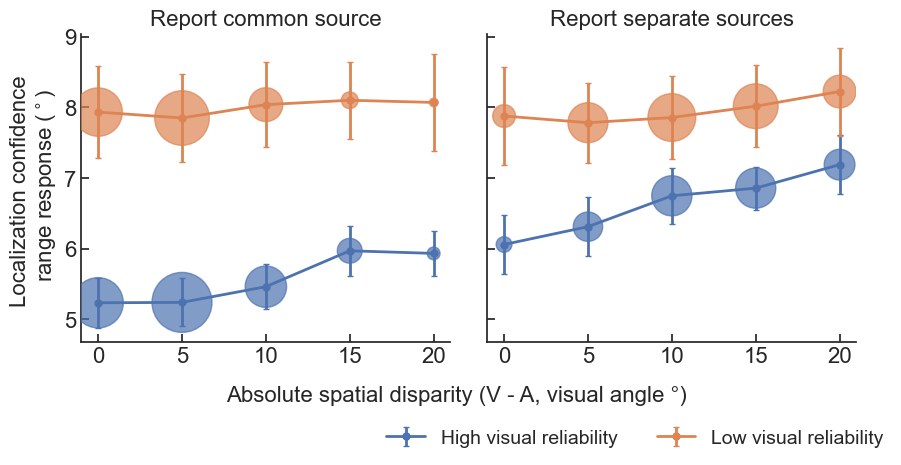

In [82]:
global_min, global_max = get_global_min_max(df=df_beh, groupvar = ["abs_delta_VA"])
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp_vrel(df=df_beh.loc[df_beh.Sources==1], ax=axs[0])
plot_CI_size_by_disp_vrel(df=df_beh.loc[df_beh.Sources==2], ax=axs[1], legend=True)
# plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==1], ax=axs[0], scale=True, global_min=global_min, global_max=global_max, power=2)
# plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==2], ax=axs[1], legend=True, scale=True, global_min=global_min, global_max=global_max, power=2)
axs[0].set_title('Report common source', fontsize=fontsize)
axs[1].set_title('Report separate sources', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization confidence \n range response ($^\\circ$)', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

Text(0, 0.5, 'Localization confidence \n rangeresponse ($^\\circ$)')

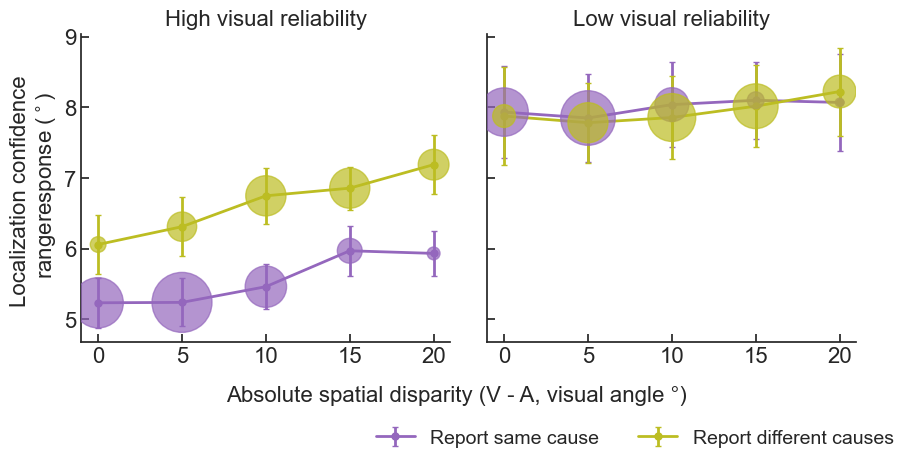

In [83]:
global_min, global_max = get_global_min_max(df=df_beh, groupvar = ["abs_delta_VA"])
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp(df=df_beh.loc[df_beh.VisRelLabel=='High'], ax=axs[0])
plot_CI_size_by_disp(df=df_beh.loc[df_beh.VisRelLabel=='Low'], ax=axs[1], legend=True)
# plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==1], ax=axs[0], scale=True, global_min=global_min, global_max=global_max, power=2)
# plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==2], ax=axs[1], legend=True, scale=True, global_min=global_min, global_max=global_max, power=2)
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization confidence \n rangeresponse ($^\\circ$)', fontsize=fontsize)
#plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

### by A locations 

m:\1confiProj\scripts\plot_function.py:406: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:419: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


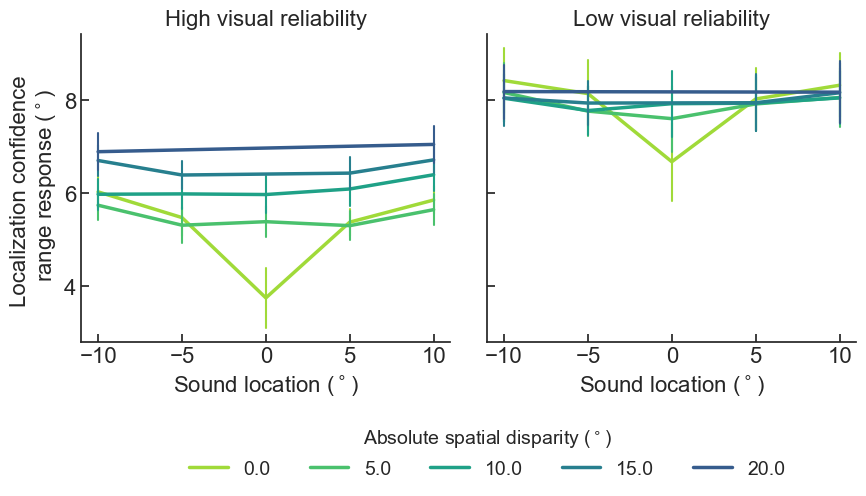

In [84]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_beh, axs=axs) 
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
#fig.supxlabel('Auditory Stimulus location ($^\\circ$)', fontsize=fontsize,y=-0.05)
plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp_and_audloc.png'), bbox_inches='tight', dpi=300)

### the variability of confidence for common congruent trials

In [85]:
df_plot = df_beh[(df_beh['Modality'] == 'A')&(df_beh.Sources==1)&(df_beh.AudLoc==df_beh.VisLoc)] #congruent common trials
summary = df_plot.groupby(['sub_id', 'VisRelLabel', 'AudLoc']).agg(ci_mean=('CISize', 'mean'), loc_std = ('RespLoc', 'std'), loc_mean = ('RespLoc', 'mean'),ci_std = ('CISize', 'std'), n=('RespLoc', 'size')).reset_index()
summary
#On subject-level, congruent common trials, plot the localization std against the mean uncertainty.  For each subject and each visual reliability, one location. , 

,sub_id,VisRelLabel,AudLoc,ci_mean,loc_std,loc_mean,ci_std,n
0,2,High,-10.0,5.187353,0.838787,-8.266176,1.646037,34
1,2,High,-5.0,4.175926,0.627923,-4.612222,0.901065,27
2,2,High,0.0,2.965294,0.510003,-0.079412,1.923725,34
3,2,High,5.0,4.877097,0.834609,4.839355,0.994723,31
4,2,High,10.0,5.123714,0.962913,8.224286,1.455117,35
...,...,...,...,...,...,...,...,...
75,25,Low,-10.0,12.180263,0.967807,-7.362368,2.225469,38
76,25,Low,-5.0,9.425000,1.079271,-4.824687,1.820030,32
77,25,Low,0.0,4.525714,2.051413,0.205429,4.183558,35
78,25,Low,5.0,10.222162,0.936040,5.622703,1.475830,37


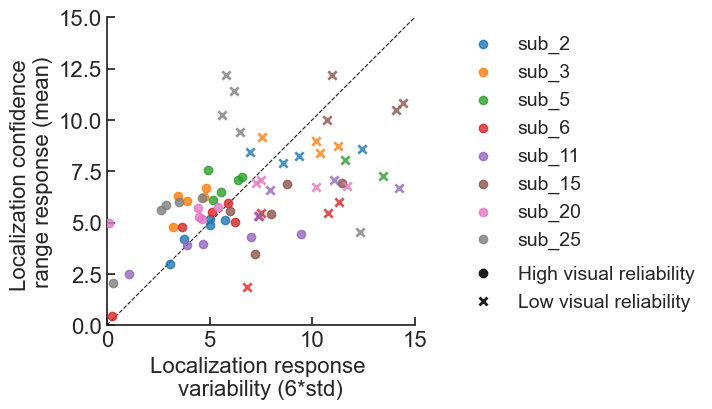

In [86]:
palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))
color_map = dict(zip(ev.dh.sub_lst_all, palette))

fig, ax = plt.subplots(figsize=(10, 4))

for sub_id in ev.dh.sub_lst_all:
    data = summary[summary["sub_id"] == sub_id].copy()
    data['loc_std'] = data['loc_std'] * 6 # to make it a square

    ax.scatter(
        data.loc[data.VisRelLabel=='High', "loc_std"],
        data.loc[data.VisRelLabel=='High', "ci_mean"],
        #s=data.loc[data.VisRelLabel=='High', "n"],
        color=color_map[sub_id],
        alpha=0.8,
        marker='o',
        zorder=3,
        label=f"sub_{sub_id}"
    )
    ax.scatter(
        data.loc[data.VisRelLabel=='Low', "loc_std"],
        data.loc[data.VisRelLabel=='Low', "ci_mean"],
        #s=data.loc[data.VisRelLabel=='Low', "n"],
        alpha=0.8,
        marker='x',
        color=color_map[sub_id],
        linewidth=2,
        zorder=4,
        #label=f"sub_{sub_id}"
    )

ax.set_xlabel("Localization response \nvariability (6*std)", fontsize=fontsize)
ax.set_ylabel(
    "Localization confidence \nrange response (mean)",
    fontsize=fontsize
)

ax.plot([0, 15], [0, 15], "--k", lw=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim([0, 15])
ax.set_ylim([0, 15])
clean_axs(ax)

# Subject legend (colors)
leg1 = ax.legend(
    bbox_to_anchor=(1.1, 1),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2,
)

# Reliability legend (markers)
reliability_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='k',
        linestyle='None',
        markersize=6,
        label='High visual reliability'
    ),
    Line2D(
        [0], [0],
        marker='x',
        color='k',
        linestyle='None',
        markersize=6,
        markeredgewidth=2,
        label='Low visual reliability'
    )
]

leg2 = ax.legend(
    handles=reliability_handles,
    bbox_to_anchor=(1.1, 0.25),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2,
    #title="Visual reliability"
)

# keep both legends
ax.add_artist(leg1)

plt.savefig(os.path.join(plot_path, 'ci_mean_loc_var_rel.png'), bbox_inches='tight', dpi=300)
plt.show()

## 3. Causal confidence

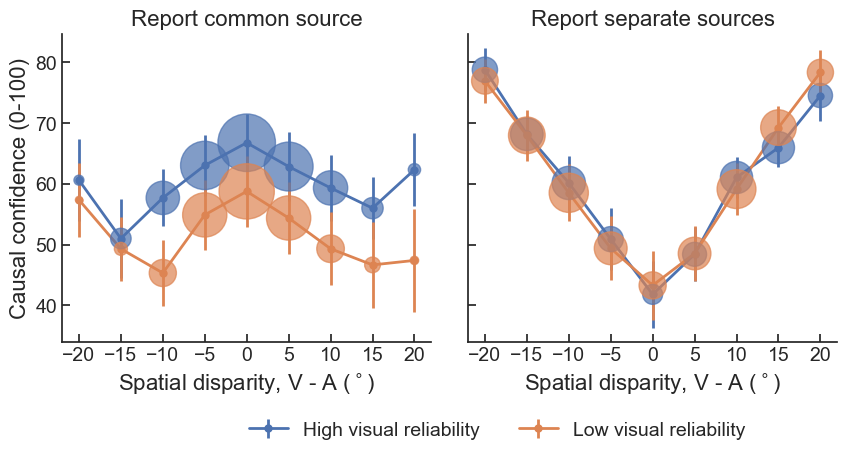

In [87]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1}
                        )
plot_casual_conf(df=df_beh.loc[df_beh.Sources==1],ax=axs[0], 
                 #trial_type='A', 
                 leg=False)
plot_casual_conf(df=df_beh.loc[df_beh.Sources==2],ax=axs[1], 
                 #trial_type='A', 
                 leg=True)

axs[0].set_title('Report common source', fontsize=fontsize, y=1)
axs[1].set_title('Report separate sources', fontsize=fontsize, y=1)
axs[0].set_ylabel('Causal confidence (0-100)', fontsize=fontsize)
fig.savefig(os.path.join(plot_path, "causal_conf_beh.png"), dpi=300, bbox_inches="tight")

### the relationship between perceptual and causal confidence

In [88]:
from scipy.stats import zscore
df_plot = df_beh[(df_beh['Modality'] == 'A')].copy()
#df_plot = df_beh[(df_beh['Modality'] == 'A')&(df_beh.Sources==1)&(df_beh.AudLoc==df_beh.VisLoc)] #congruent common trials

# Standardize data relative to each subject's individual mean/std
df_plot['CISize_z'] = df_plot.groupby('sub_id')['CISize'].transform(zscore)
df_plot['ConfLevel_z'] = df_plot.groupby('sub_id')['ConfLevel'].transform(zscore)

summary = df_plot.groupby(['sub_id', 'VisRelLabel', 'delta_VA', 'Sources']).agg(
    ci_mean=('CISize', 'mean'), 
    cc_std = ('ConfLevel', 'std'), 
    cc_mean = ('ConfLevel', 'mean'),
    ci_std = ('CISize', 'std'), 
    n=('RespLoc', 'size'),
    ci_cv=('CISize', lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan),
    cc_cv=('ConfLevel', lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan),
    ci_zscore = ('CISize_z', 'mean'),
    cc_zscore = ('ConfLevel_z', 'mean')).reset_index()
#summary['Sources']=1
#On subject-level, congruent common trials, plot the localization std against the mean uncertainty.  For each subject and each visual reliability, one location. , 

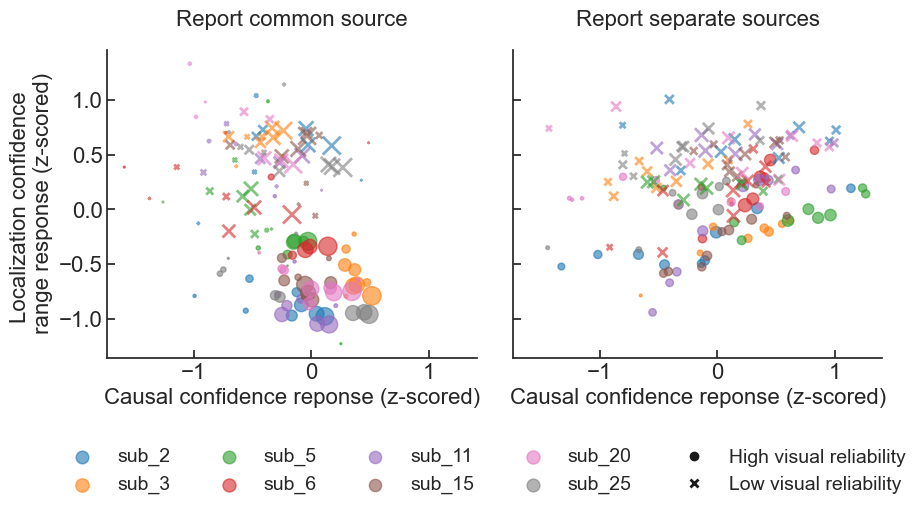

In [89]:
fig, axs = plt.subplots(
    nrows=1, ncols=2,
    sharey=True,
    sharex=True,
    figsize=(10, 4),
    gridspec_kw={'wspace':0.1}
)

xvar, xlabel = 'cc_zscore', 'Causal confidence reponse (z-scored)'
yvar, ylabel = 'ci_zscore', 'Localization confidence \nrange response (z-scored)'
titles = ["Report common source", "Report separate sources"] 

palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))
color_map = dict(zip(ev.dh.sub_lst_all, palette))

for sub_id in ev.dh.sub_lst_all:
    sub_data = summary[summary["sub_id"] == sub_id]

    for col, sour in enumerate([1, 2]):
        data = sub_data[(sub_data["Sources"] == sour)]

        axs[col].scatter(
            data.loc[data.VisRelLabel=='High', xvar],
            data.loc[data.VisRelLabel=='High',yvar],
            s=data.loc[data.VisRelLabel=='High', "n"],
            color=color_map[sub_id],
            alpha=0.6,
            zorder=3,
            label=f"sub_{sub_id}"
        )
        axs[col].scatter(
            data.loc[data.VisRelLabel=='Low', xvar],
            data.loc[data.VisRelLabel=='Low',yvar],
            s=data.loc[data.VisRelLabel=='Low', "n"],
            alpha=0.6,
            marker='x',
            color=color_map[sub_id],
            linewidth=2,
            zorder=4,
            #label=f"sub_{sub_id}"
        )

        clean_axs(axs[col]) 
        axs[col].set_xlabel(xlabel, fontsize=fontsize)
        axs[col].set_title(titles[col], fontsize=fontsize, y=1.05)

axs[0].set_ylabel(ylabel, fontsize=fontsize)

axs[0].legend(
    bbox_to_anchor=(0.65, -0.5),
    loc="lower center",
    frameon=False,
    fontsize=fontsize-2,
    ncols=4
)

# Reliability legend (markers)
reliability_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='k',
        linestyle='None',
        markersize=6,
        label='High visual reliability'
    ),
    Line2D(
        [0], [0],
        marker='x',
        color='k',
        linestyle='None',
        markersize=6,
        markeredgewidth=2,
        label='Low visual reliability'
    )
]

axs[1].legend(
    handles=reliability_handles,
    bbox_to_anchor=(0.75, -0.5),
    loc="lower center",
    frameon=False,
    fontsize=fontsize-2,
    #title="Visual reliability"
)

fig.savefig(os.path.join(plot_path, "cc_ci_relation_v2.png"), dpi=300, bbox_inches="tight")
plt.show()


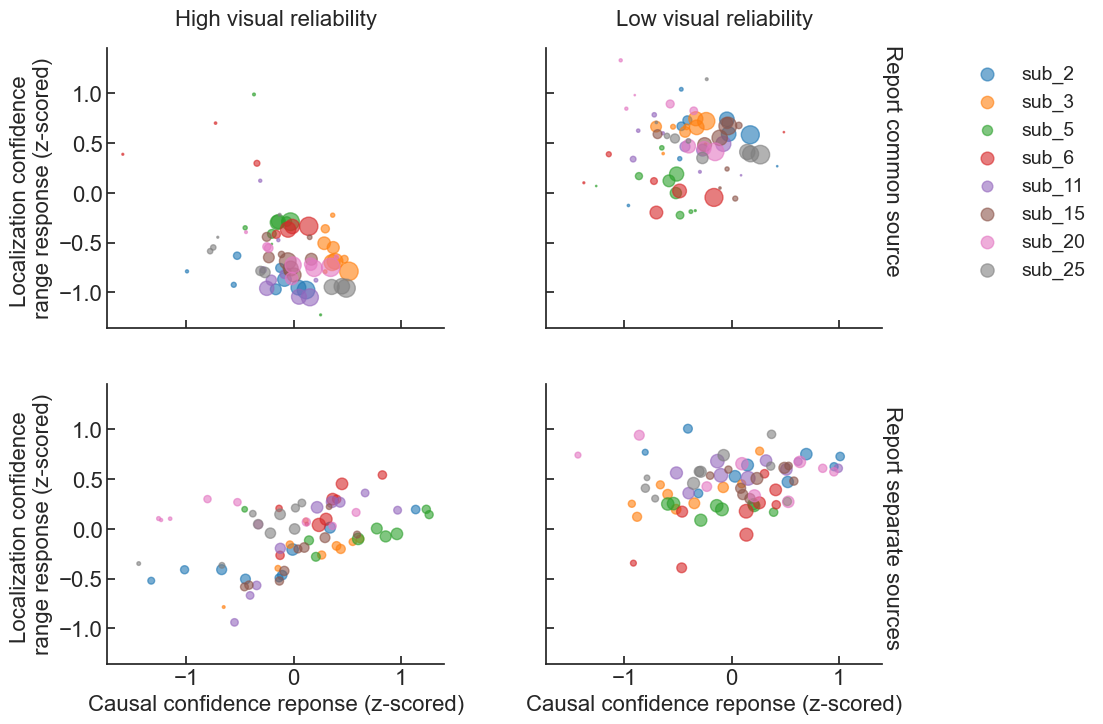

In [90]:
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    sharey=True,
    sharex=True,
    figsize=(10, 8),
    gridspec_kw={'hspace':0.2, 'wspace':0.3}
)

xvar, xlabel = 'cc_zscore', 'Causal confidence reponse (z-scored)'
yvar, ylabel = 'ci_zscore', 'Localization confidence \nrange response (z-scored)'
# Generate color palette mapping
# palette = sns.color_palette("colorblind", n_colors=len(ev.dh.sub_lst_all))
# color_map = dict(zip(ev.dh.sub_lst_all, palette))

palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))
color_map = dict(zip(ev.dh.sub_lst_all, palette))

# 2. Plotting loop
for sub_id in ev.dh.sub_lst_all:
    sub_data = summary[summary["sub_id"] == sub_id]

    for col, vis_rel in enumerate(["High", "Low"]):
        for row, sour in enumerate([1, 2]):
            data = sub_data[(sub_data["VisRelLabel"] == vis_rel) & (sub_data["Sources"] == sour)]

            axs[row, col].scatter(
                data[xvar],
                data[yvar],
                s=data["n"],
                color=color_map[sub_id],
                alpha=0.6,
                zorder=3,
                label=f"sub_{sub_id}"
            )

# 3. Corrected Formatting Loops (Explicitly iterating through rows and columns)
titles = ["High visual reliability", "Low visual reliability"]
y_labels = ["Same", "Different"] # Adjust labels if needed

for row in range(2):
    for col in range(2):
        # Apply your cleaning function safely to every axis
        clean_axs(axs[row, col]) 
        
        # Set X-labels only for the bottom row to prevent overlaps
        if row == 1:
            axs[row, col].set_xlabel(xlabel, fontsize=fontsize)
            
        # Set Titles only for the top row
        if row == 0:
            axs[row, col].set_title(titles[col], fontsize=fontsize, y=1.05)

# Set Y-labels cleanly on the leftmost subplots
for ax in axs[:,0]:
    ax.set_ylabel(ylabel,
            fontsize=fontsize)
# axs[0, 0].set_ylabel(f"{y_labels[0]}\nLocalization uncertainty (mean)", fontsize=fontsize)
# axs[1, 0].set_ylabel(f"{y_labels[1]}\nLocalization uncertainty (mean)", fontsize=fontsize)

# 4. Global legend handled outside the plot boundary
axs[0, 1].legend(
    title="",
    bbox_to_anchor=(1.2, 1),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2
)

fig.text(
        0.9, 0.74, 'Report common source',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

fig.text(
    0.9, 0.28, 'Report separate sources',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)
# Use bbox_inches="tight" during save to prevent cutting off the legend
fig.savefig(os.path.join(plot_path, "cc_ci_relation.png"), dpi=300, bbox_inches="tight")
plt.show()


# Model simulation analysis

## 1. Localization raw data

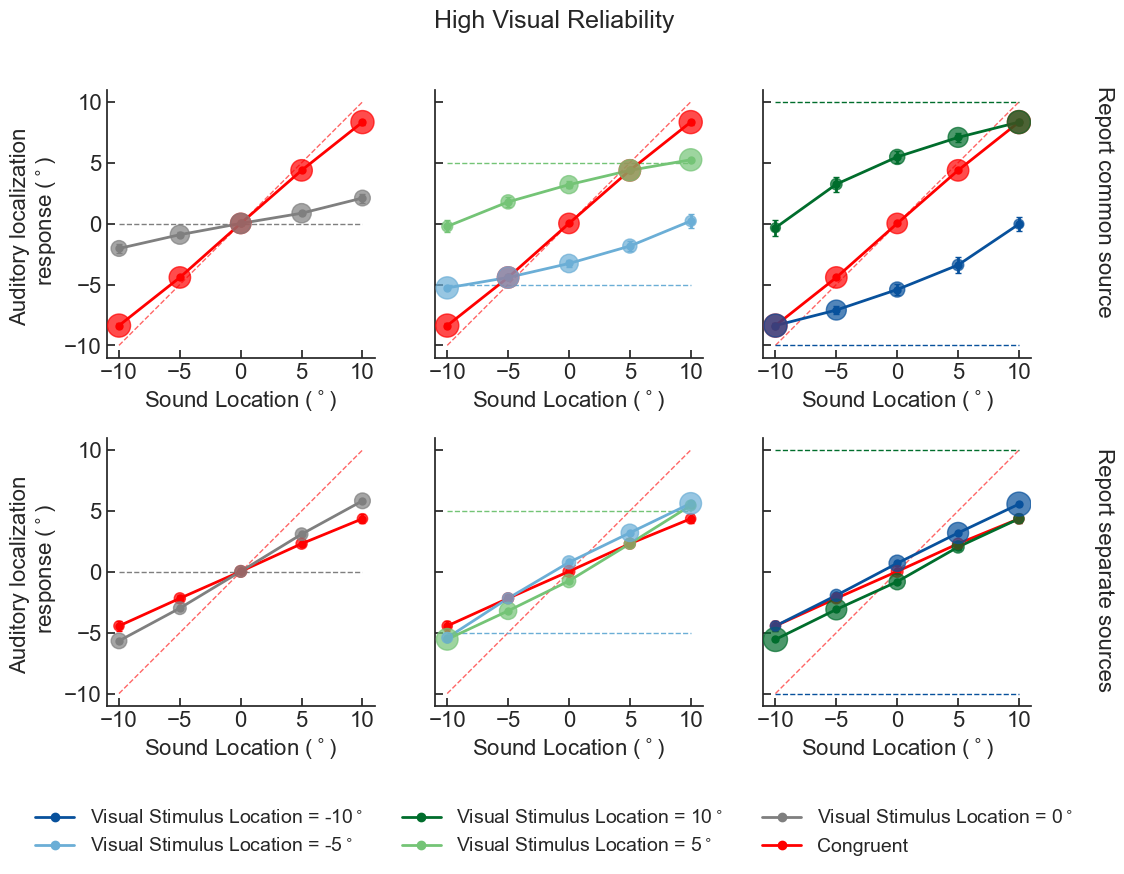

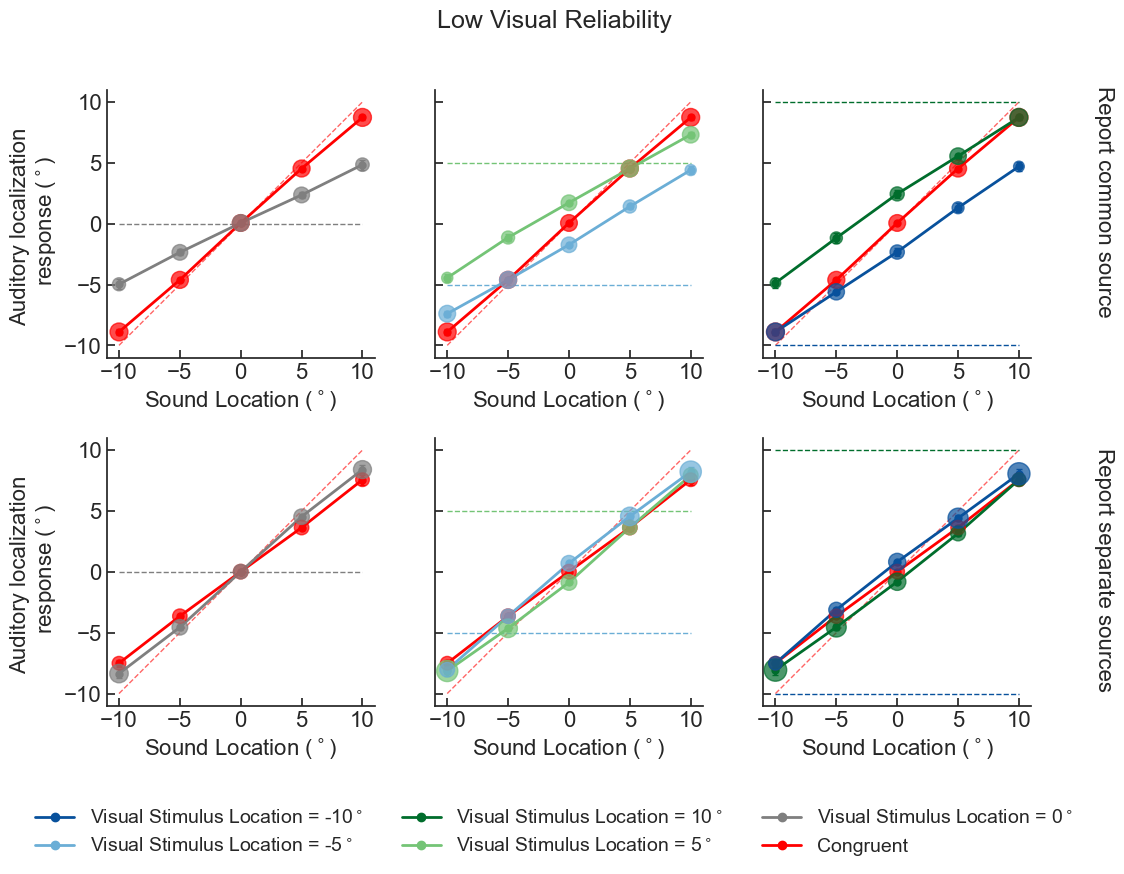

In [91]:
# compute the cross-condition counts min and max for scaling function
global_min, global_max = get_global_min_max(df=df_sim, groupvar = ["AudLoc", "VisLoc"])

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace':0.2, 'hspace': 0.3}
    )

    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_all(
                df=df_sim.loc[(df_sim.Sources == sources)&(df_sim.m_id==2)],
                rel=vrel,
                ax=axs[row, col],
                visloc=visloc,
                #resp_var='CISize',
                legend=False,
                palette=palette_vloc,
                scale = True,
                global_min=global_min,
                global_max = global_max,
                power=2
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color=palette_vloc[vloc],
            lw=2,
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    legend_elements.append(
                       Line2D(
                        [0], [0],
                        color='red',
                        lw=2,
                        marker='o',
                        markersize=6,
                        markerfacecolor='red',
                        markeredgecolor='red',
                        label="Congruent",
                    ))
    fig.legend(
        handles=legend_elements,
        title='',
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)

    axs[1,0].set_ylabel('Auditory localization \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Auditory localization \n response ($^\\circ$)', fontsize=fontsize)

    fig.text(
        0.95, 0.74, 'Report common source',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.95, 0.28, 'Report separate sources',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )
    #fig.supylabel('Auditory Response Location', fontsize=fontsize)
    plt.savefig(os.path.join(plot_path,'models', f'M_raw_re_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

## 2.Localization uncertainty estimate

### by spatial disparity

In [92]:
# QUICK ADHOC TO SEE HOW MUCH THE TRIAL SCALES
sim_min, sim_max = get_global_min_max(df=df_sim, groupvar=['abs_delta_VA', 'sub_id'], modality='A')
beh_min, beh_max = get_global_min_max(df=df_beh, groupvar=['abs_delta_VA', 'sub_id'], modality='A')
sim_max/beh_max

np.float64(25.810909090909092)

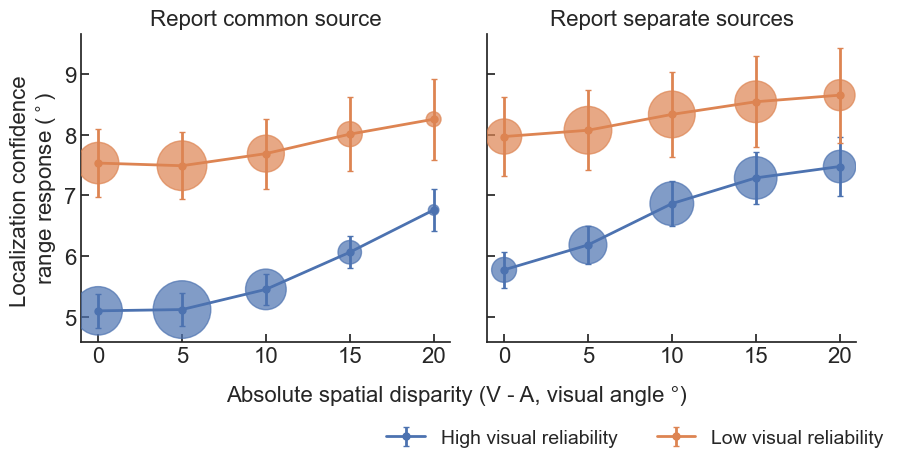

In [93]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp_vrel(df=df_sim.loc[df_sim.Sources==1], m_id = 2, ax=axs[0], scale=True, k=26)
plot_CI_size_by_disp_vrel(df=df_sim.loc[df_sim.Sources==2], m_id = 2, ax=axs[1], legend=True, scale=True, k=26)
axs[0].set_title('Report common source', fontsize=fontsize)
axs[1].set_title('Report separate sources', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization confidence \nrange response ($^\\circ$)', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models', 'M_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

### by A locations 

m:\1confiProj\scripts\plot_function.py:406: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:419: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


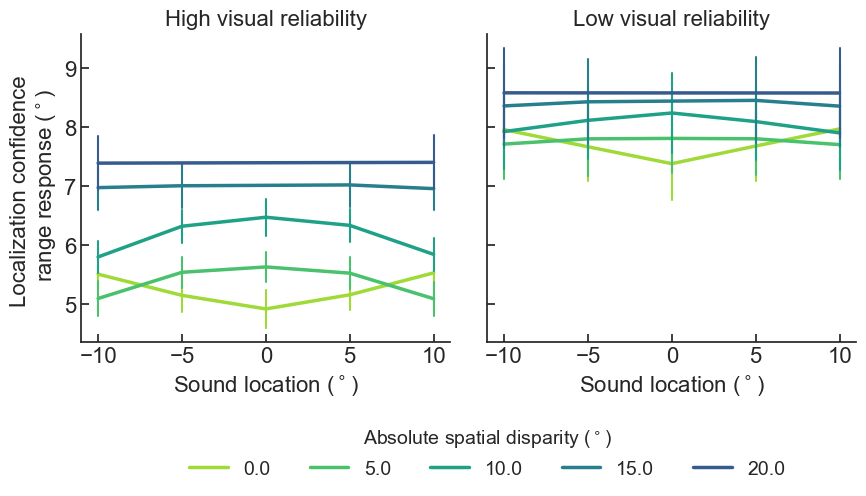

In [94]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_sim, m_id=2, axs=axs) 
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models', 'M_ci_by_causal_disp_and_audloc.png'), bbox_inches='tight', dpi=300)

## 3. Causal confidence

In [95]:
# QUICK ADHOC TO SEE HOW MUCH THE TRIAL SCALES
sim_min, sim_max = get_global_min_max(df=df_sim, groupvar=['delta_VA', 'sub_id'], modality='A')
beh_min, beh_max = get_global_min_max(df=df_beh, groupvar=['delta_VA', 'sub_id'], modality='A')
sim_max/beh_max

np.float64(26.685393258426966)

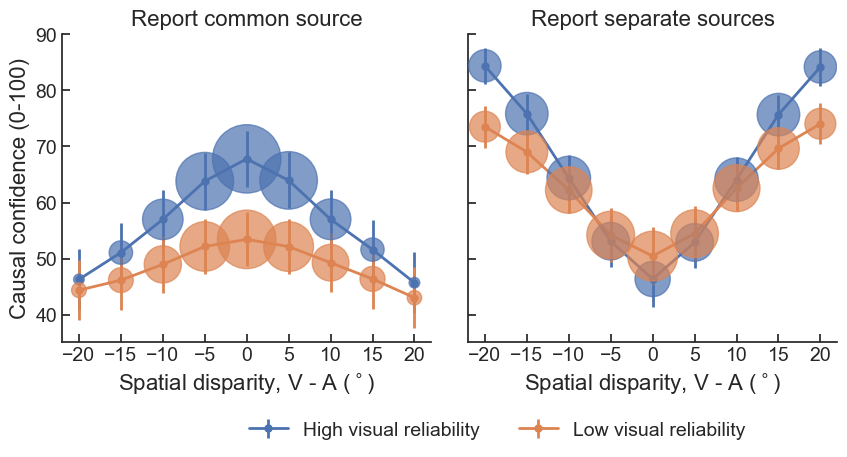

In [96]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1}
                        )
plot_casual_conf(df=df_sim.loc[(df_sim.Sources==1)&(df_sim.m_id==2)],ax=axs[0], 
                 #trial_type='A', 
                 scale=True,
                 k=26,
                 leg=False)
plot_casual_conf(df=df_sim.loc[(df_sim.Sources==2)&(df_sim.m_id==2)],ax=axs[1], 
                 #trial_type='A', 
                 scale=True,
                 k=26,
                 leg=True)

axs[0].set_title('Report common source', fontsize=fontsize, y=1)
axs[1].set_title('Report separate sources', fontsize=fontsize, y=1)

axs[0].set_ylabel('Causal confidence (0-100)', fontsize=fontsize)
fig.savefig(os.path.join(plot_path, 'models', "M_causal_conf.png"), dpi=300, bbox_inches="tight")

## 4.Formal model comparison

In [2]:
exp_name1 = 'with_dn'
CM = CompareModels(exp_name1)
m_lst= [2, 8]
df_ev, df_best_model = CM.compare_models(m1_list=m_lst, best_by='BIC', by_nll='train')


 ------- Start Aggregating for Subject 2 ---------- 

 ------- Start Aggregating for Subject 3 ---------- 

 ------- Start Aggregating for Subject 5 ---------- 

 ------- Start Aggregating for Subject 6 ---------- 

 ------- Start Aggregating for Subject 11 ---------- 

 ------- Start Aggregating for Subject 15 ---------- 

 ------- Start Aggregating for Subject 20 ---------- 

 ------- Start Aggregating for Subject 25 ---------- 

 ------- Start Aggregating for Subject 2 ---------- 

 ------- Start Aggregating for Subject 3 ---------- 

 ------- Start Aggregating for Subject 5 ---------- 

 ------- Start Aggregating for Subject 6 ---------- 

 ------- Start Aggregating for Subject 11 ---------- 

 ------- Start Aggregating for Subject 15 ---------- 

 ------- Start Aggregating for Subject 20 ---------- 

 ------- Start Aggregating for Subject 25 ---------- 


In [98]:
df_best_model

,m_id,exp,sub_id,AIC,AICc,BIC,nll,npar,best_par,nll_method,CI_readout,est_var,Causal_readout
0,2,with_dn,2,38879.948060,38880.144781,38967.042399,19424.974030,15,"[1.516388643831969, 6.115413665771484, 5.75046...",QML,BayInt,MS,Bay
1,2,with_dn,3,36902.576472,36902.776639,36989.412078,18436.288236,15,"[0.9809599534726389, 4.51078274846077, 5.64426...",QML,BayInt,MS,Bay
2,2,with_dn,5,37612.784906,37612.984740,37699.645347,18791.392453,15,"[4.999155771124362, 6.590072721242905, 7.45021...",QML,BayInt,MS,Bay
3,2,with_dn,6,33685.910490,33686.110323,33772.770930,16827.955245,15,"[0.9842586739170013, 1.341536596417427, 4.2476...",QML,BayInt,MS,Bay
4,8,with_dn,11,35300.308519,35300.459745,35375.603686,17637.154260,13,"[1.2583253657213185, 4.529961004853249, 6.0629...",QML,lin_sig,MS,Bay
5,2,with_dn,15,36306.320364,36306.516844,36393.433014,18138.160182,15,"[2.513487877667718, 7.056974112987518, 9.10948...",QML,BayInt,MS,Bay
6,2,with_dn,20,34162.323671,34162.525014,34249.072031,17066.161836,15,"[1.1057594435557667, 4.396740764379501, 6.1010...",QML,BayInt,MS,Bay
7,2,with_dn,25,37795.304731,37795.502262,37882.337871,18882.652366,15,"[2.5022474917499617, 5.255873918533325, 5.4879...",QML,BayInt,MS,Bay


In [ ]:
if 0:
    # Expand best_par into separate columns
    df_best_model2 = df_ev.loc[df_ev[df_ev.m_id==2].groupby(['sub_id'])['BIC'].idxmin(), :].reset_index(drop=True)
    model = CM.ev_exp1.get_model(2)
    par_cols = pd.DataFrame(
        df_best_model2['best_par'].tolist(),
        index=df_best_model2.sub_id,
        columns=model.estParamsNames  # optional names
    )

    # Join back to original dataframe
    df_export = pd.concat([df_best_model2.drop(columns='best_par'), par_cols], axis=1)

    # Export to Excel
    df_export.to_excel(os.path.join(plot_path, 'model_evaluation_results.xlsx'), index=False)

In [99]:
df_allsub = []
for sid in CM.sub_lst:
    df_sub = CM.ev_exp1.dh.get_sub_fit_data(m_id=8, exp_name=exp_name1, sub_id=sid, read_pkl=True)
    df_allsub.append(df_sub)

df_allsub = pd.concat(df_allsub, ignore_index=True)

In [100]:
df_allsub

,run_id,model_id,sub_id,nfold,train_nll,est_params,init_params,runtime,success
0,20260728_205638,8,2,0,24631.855164,"[2.4080007785390203, 9.074766159057617, 8.4485...","[1.9846690401072997, 4.476028788200614, 7.1441...",78.515047,True
1,20260728_215212,8,2,0,24617.840613,"[0.8737694715003103, 7.091179370880127, 6.8977...","[0.08288628802718334, 3.3345571177249864, 12.4...",55.575912,True
2,20260731_062556,8,2,0,19497.967431,"[1.915678487571216, 5.165870666503906, 4.91744...","[1.4403330471787925, 5.902745521708191, 3.5636...",74.165887,True
3,20260731_073337,8,2,0,24577.651667,"[1.7186209469356588, 3.8500243425369263, 3.521...","[0.7464151309886776, 6.4843409962577745, 11.56...",67.681675,True
4,20260804_211419,8,2,0,24597.886775,"[2.3884862706905112, 5.432225659489632, 5.1276...","[1.320004327813805, 4.7726051116652926, 3.2334...",43.182408,True
...,...,...,...,...,...,...,...,...,...
235,20260729_122256,8,25,0,18937.370917,"[1.9565995252883561, 4.40997314453125, 5.05094...","[0.15470223523090648, 9.696519346007324, 2.630...",63.378011,True
236,20260805_114715,8,25,0,23019.308828,"[0.0017119763682509482, 0.76904296875, 4.21136...","[1.8713956433452419, 2.070275313940696, 11.414...",46.751765,True
237,20260805_125809,8,25,0,22157.015269,"[1.530580667369141, 3.138350248336792, 3.57481...","[1.9032715111316203, 8.31484037752227, 13.1229...",70.885925,True
238,20260805_142337,8,25,0,22506.368837,"[1.586376658841391, 3.9009335041046143, 4.2098...","[1.7624268566947874, 2.7927805423476046, 2.113...",85.467198,True


In [101]:
#number of run for each subjects
df_allsub.groupby(['model_id', 'sub_id']).size().reset_index()

,model_id,sub_id,0
0,8,2,30
1,8,3,30
2,8,5,30
3,8,6,30
4,8,11,30
5,8,15,30
6,8,20,30
7,8,25,30


In [102]:
df_ev_plot = df_ev.loc[df_ev.groupby(['m_id', 'sub_id'])['BIC'].idxmin(), :].reset_index(drop=True)
bic_diff = (
    df_ev_plot.pivot(index='sub_id', columns='m_id', values='BIC')
)
bic_diff['diff'] = bic_diff[2] - bic_diff[8]
bic_diff['sub_id'] = bic_diff.index.astype(str)
bic_diff

m_id,2,8,diff,sub_id
sub_id,,,,
2,38967.042399,39097.416624,-130.374225,2
3,36989.412078,37697.160988,-707.748910,3
5,37699.645347,37923.865186,-224.219840,5
6,33772.770930,33909.769645,-136.998715,6
11,35674.826048,35375.603686,299.222361,11
15,36393.433014,36603.805828,-210.372814,15
20,34249.072031,34473.189494,-224.117463,20
25,37882.337871,37955.832135,-73.494264,25


C:\Users\wenlou\AppData\Local\Temp\ipykernel_10608\2003893134.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


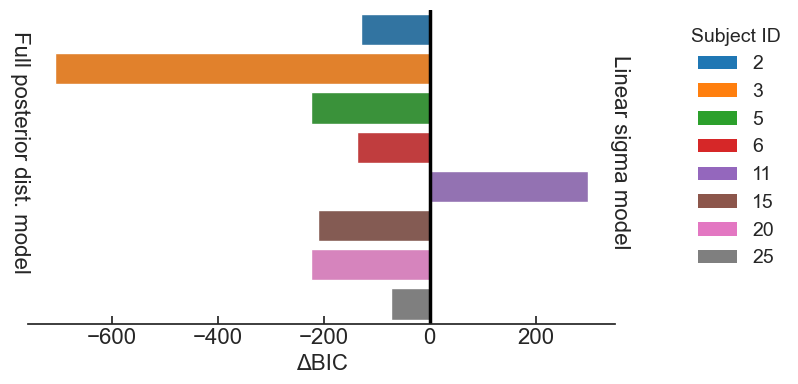

In [108]:
#barplot of BIC for each model and each subject
from matplotlib.patches import Patch
palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=bic_diff,
    x='diff',
    y='sub_id',
    palette=palette,
    orient='h',
    ax=ax
)

# Thick vertical reference line at x = 0
ax.axvline(0, color='black', linewidth=2.5)

# Labels
ax.set_xlabel('ΔBIC', fontsize=fontsize, y = -0.5)
ax.set_ylabel('')
ax.set_yticklabels('')
ax.tick_params(axis='x', which='major', direction='in', left=True, bottom=True, labelsize=fontsize)
ax.xaxis.set_major_locator(MultipleLocator(200))
# Clean up spines
sns.despine(ax=ax, top=True, right=True, left=True, bottom=False)

# Create legend handles
handles = [
    Patch(facecolor=palette[i], edgecolor='none', label=f'{sub}')
    for i, sub in enumerate(ev.dh.sub_lst_all)
]

ax.legend(
    handles=handles,
    title='Subject ID',
    bbox_to_anchor=(1.1, 1),
    loc='upper left',
    frameon=False,
    fontsize=fontsize-2,
    title_fontsize=fontsize-2,
    ncol=1,  
)

fig.text(
        0.75, 0.6, 'Linear sigma model',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

fig.text(
    0, 0.6, 'Full posterior dist. model',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)

plt.tight_layout()
fig.savefig(os.path.join(plot_path, 'BIC_diff.png'), bbox_inches='tight', dpi=300)
plt.show()


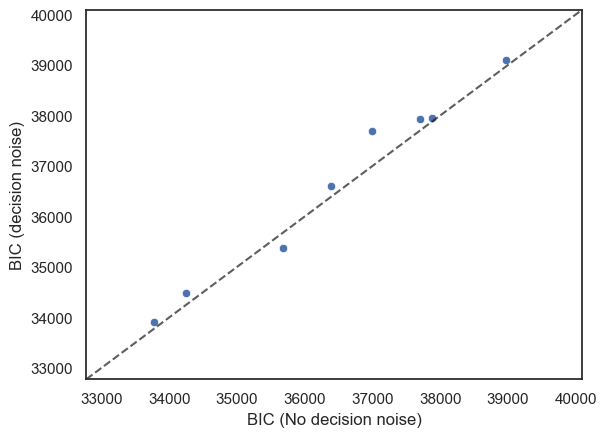

In [104]:
# two models comparison plot BIC aganist BIC
sns.scatterplot(x=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True), y=df_ev.loc[(df_ev.m_id==m_lst[1]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True))
lims = [
    df_ev.BIC.min()-1000,  # lowest value across both
    df_ev.BIC.max()+1000   # highest value across both
]
plt.xlim(lims)
plt.ylim(lims)

# Add diagonal y=x line
plt.plot(lims, lims, 'k--', alpha=0.7)

plt.xlabel("BIC (No decision noise)")
plt.ylabel("BIC (decision noise)")

plt.show()

In [105]:
# exp_name1, exp_name2 = 'with_dn_linear', 'with_dn'
# CM=CompareModels(exp_name1, exp_name2)
# m_lst= [2]
# df_ev, df_best_model = CM.compare_models(m1_list=m_lst, m2_list=m_lst, best_by='BIC', by_nll='train')

## Supplementary the model prediction from mterduced models

### without decision noise

In [4]:
### prepare model simulation data
m_label = 'test_causal_bin1'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim_supp = pd.concat(df_sim_lst, ignore_index=True)


Model 2 subjects:   0%|          | 0/8 [00:00<?, ?subject/s]


 ------- Start Aggregating for Subject 2 ---------- 


Model 2 subjects:  12%|█▎        | 1/8 [00:00<00:02,  3.06subject/s]


 ------- Start Aggregating for Subject 3 ---------- 


Model 2 subjects:  25%|██▌       | 2/8 [00:00<00:01,  3.20subject/s]

...

Model 2 subjects:  75%|███████▌  | 6/8 [00:02<00:00,  2.50subject/s]


 ------- Start Aggregating for Subject 20 ---------- 


Model 2 subjects:  88%|████████▊ | 7/8 [00:02<00:00,  2.61subject/s]


 ------- Start Aggregating for Subject 25 ---------- 


Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  2.70subject/s]


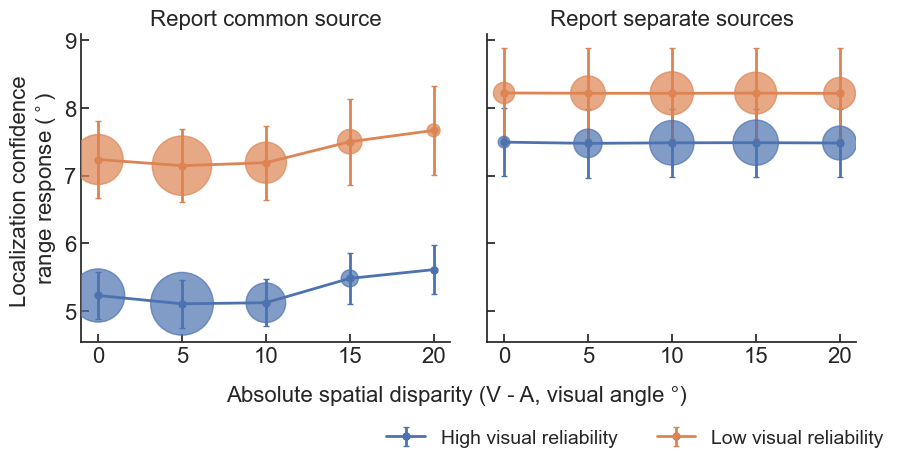

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp_vrel(df=df_sim_supp.loc[df_sim_supp.Sources==1], m_id = 2, ax=axs[0], scale=True, k=26)
plot_CI_size_by_disp_vrel(df=df_sim_supp.loc[df_sim_supp.Sources==2], m_id = 2, ax=axs[1], legend=True, scale=True, k=26)
axs[0].set_title('Report common source', fontsize=fontsize)
axs[1].set_title('Report separate sources', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization confidence \nrange response ($^\\circ$)', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models_supp', 'M_ci_by_causal_disp_no_dn.png'), bbox_inches='tight', dpi=300)

### without eccentricity

In [6]:
### prepare model simulation data
m_label = 'with_dn_reduced'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim_supp = pd.concat(df_sim_lst, ignore_index=True)

Model 2 subjects:   0%|          | 0/8 [00:00<?, ?subject/s]


 ------- Start Aggregating for Subject 2 ---------- 


Model 2 subjects:  12%|█▎        | 1/8 [00:00<00:03,  2.16subject/s]


 ------- Start Aggregating for Subject 3 ---------- 


Model 2 subjects:  25%|██▌       | 2/8 [00:00<00:02,  2.90subject/s]

...

Model 2 subjects:  75%|███████▌  | 6/8 [00:01<00:00,  3.43subject/s]


 ------- Start Aggregating for Subject 20 ---------- 


Model 2 subjects:  88%|████████▊ | 7/8 [00:02<00:00,  3.27subject/s]


 ------- Start Aggregating for Subject 25 ---------- 


Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  3.32subject/s]


m:\1confiProj\scripts\plot_function.py:406: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:419: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


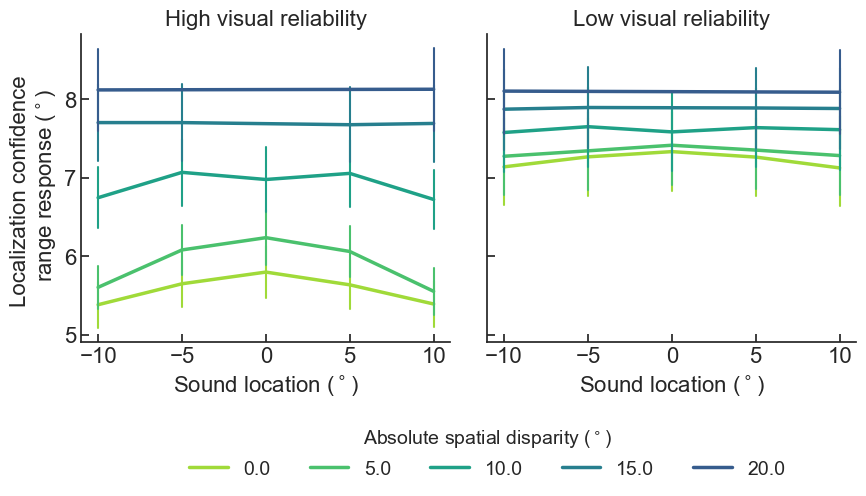

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_sim_supp, m_id=2, axs=axs) 
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models_supp', 'M_ci_by_causal_disp_and_audloc_noecc.png'), bbox_inches='tight', dpi=300)

### shared noise

In [9]:
### prepare model simulation data
m_label = 'with_dn_ecc'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim_supp = pd.concat(df_sim_lst, ignore_index=True)

Model 2 subjects:   0%|          | 0/8 [00:00<?, ?subject/s]


 ------- Start Aggregating for Subject 2 ---------- 


Model 2 subjects:  12%|█▎        | 1/8 [00:00<00:03,  2.20subject/s]


 ------- Start Aggregating for Subject 3 ---------- 


Model 2 subjects:  25%|██▌       | 2/8 [00:00<00:02,  2.45subject/s]

...

Model 2 subjects:  75%|███████▌  | 6/8 [00:02<00:00,  2.62subject/s]


 ------- Start Aggregating for Subject 20 ---------- 


Model 2 subjects:  88%|████████▊ | 7/8 [00:02<00:00,  2.77subject/s]


 ------- Start Aggregating for Subject 25 ---------- 


Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  2.71subject/s]


m:\1confiProj\scripts\plot_function.py:406: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:419: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


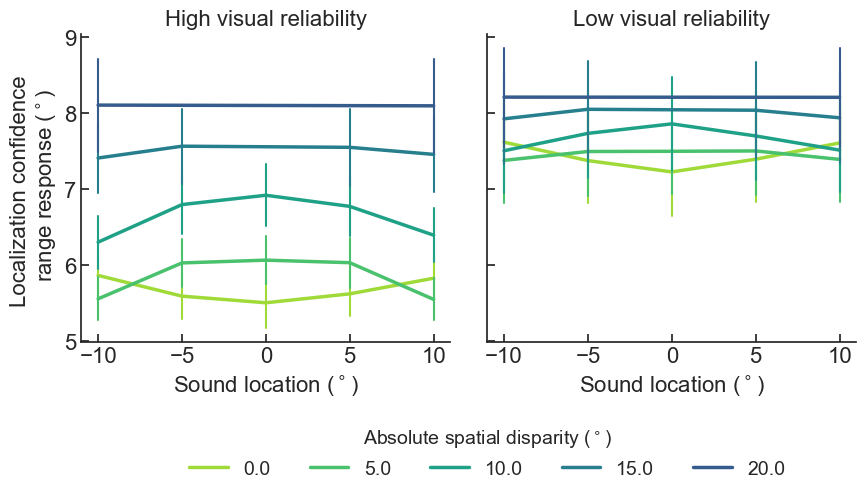

In [10]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_sim_supp, m_id=2, axs=axs) 
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models_supp', 'M_ci_by_causal_disp_and_audloc_share_noise.png'), bbox_inches='tight', dpi=300)

In [11]:
exp_name1, exp_name2 = 'with_dn_ecc', 'with_dn'
CM=CompareModels(exp_name1, exp_name2)
m_lst= [2]
df_ev, df_best_model = CM.compare_models(m1_list=m_lst, m2_list=m_lst, best_by='BIC', by_nll='train')


 ------- Start Aggregating for Subject 2 ---------- 

 ------- Start Aggregating for Subject 3 ---------- 

 ------- Start Aggregating for Subject 5 ---------- 

 ------- Start Aggregating for Subject 6 ---------- 

 ------- Start Aggregating for Subject 11 ---------- 

 ------- Start Aggregating for Subject 15 ---------- 

 ------- Start Aggregating for Subject 20 ---------- 

 ------- Start Aggregating for Subject 25 ---------- 

 ------- Start Aggregating for Subject 2 ---------- 

 ------- Start Aggregating for Subject 3 ---------- 

 ------- Start Aggregating for Subject 5 ---------- 

 ------- Start Aggregating for Subject 6 ---------- 

 ------- Start Aggregating for Subject 11 ---------- 

 ------- Start Aggregating for Subject 15 ---------- 

 ------- Start Aggregating for Subject 20 ---------- 

 ------- Start Aggregating for Subject 25 ---------- 


In [13]:
df_ev

,m_id,exp,sub_id,AIC,AICc,BIC,nll,npar,best_par,nll_method,CI_readout,est_var,Causal_readout
0,2,with_dn_ecc,2,40577.754543,40577.903601,40653.236303,20275.877271,13,"[2.2083598464434533, 8.55062484741211, 9.73292...",QML,BayInt,MS,Bay
1,2,with_dn_ecc,3,38019.958819,38020.110486,38095.216344,18996.979410,13,"[4.6809957577231085, 8.101425170898438, 8.1592...",QML,BayInt,MS,Bay
2,2,with_dn_ecc,5,37922.171336,37922.322750,37997.450384,18948.085668,13,"[4.970926992818769, 6.309683784842491, 7.33896...",QML,BayInt,MS,Bay
3,2,with_dn_ecc,6,34972.401883,34972.553297,35047.680931,17473.200942,13,"[2.1286739826212218, 2.449306607246399, 5.9177...",QML,BayInt,MS,Bay
4,2,with_dn_ecc,11,37229.691695,37229.842921,37304.986863,18601.845848,13,"[2.996735953689687, 9.418322041630745, 10.2544...",QML,BayInt,MS,Bay
5,2,with_dn_ecc,15,40125.501788,40125.650663,40200.999419,20049.750894,13,"[2.3780949871062202, 7.352806091308594, 9.8664...",QML,BayInt,MS,Bay
6,2,with_dn_ecc,20,35389.151105,35389.303662,35464.333017,17681.575553,13,"[1.2028312328651871, 4.847366213798523, 6.2627...",QML,BayInt,MS,Bay
7,2,with_dn_ecc,25,39448.070703,39448.220374,39523.499424,19711.035352,13,"[3.2870617984717603, 8.222184002399445, 8.5936...",QML,BayInt,MS,Bay
8,2,with_dn,2,38879.948060,38880.144781,38967.042399,19424.974030,15,"[1.516388643831969, 6.115413665771484, 5.75046...",QML,BayInt,MS,Bay
9,2,with_dn,3,36902.576472,36902.776639,36989.412078,18436.288236,15,"[0.9809599534726389, 4.51078274846077, 5.64426...",QML,BayInt,MS,Bay


In [16]:
df_ev_plot = df_ev.loc[df_ev.groupby(['exp', 'sub_id'])['BIC'].idxmin(), :].reset_index(drop=True)
bic_diff = (
    df_ev_plot.pivot(index='sub_id', columns='exp', values='BIC')
)
bic_diff['diff'] = bic_diff['with_dn'] - bic_diff['with_dn_ecc']
bic_diff['sub_id'] = bic_diff.index.astype(str)
bic_diff

exp,with_dn,with_dn_ecc,diff,sub_id
sub_id,,,,
2,38967.042399,40653.236303,-1686.193905,2
3,36989.412078,38095.216344,-1105.804267,3
5,37699.645347,37997.450384,-297.805037,5
6,33772.770930,35047.680931,-1274.910001,6
11,35674.826048,37304.986863,-1630.160815,11
15,36393.433014,40200.999419,-3807.566404,15
20,34249.072031,35464.333017,-1215.260986,20
25,37882.337871,39523.499424,-1641.161553,25


C:\Users\wenlou\AppData\Local\Temp\ipykernel_3944\1749505010.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


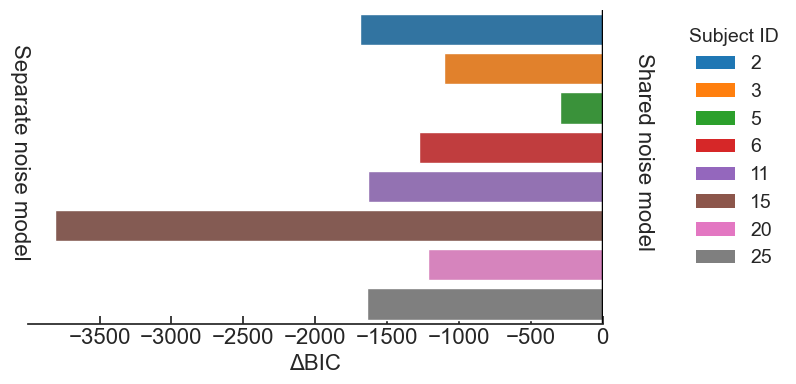

In [22]:
#barplot of BIC for each model and each subject
from matplotlib.patches import Patch
palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=bic_diff,
    x='diff',
    y='sub_id',
    palette=palette,
    orient='h',
    ax=ax
)

# Thick vertical reference line at x = 0
ax.axvline(0, color='black', linewidth=2.5)

# Labels
ax.set_xlabel('ΔBIC', fontsize=fontsize, y = -0.5)
ax.set_ylabel('')
ax.set_yticklabels('')
ax.tick_params(axis='x', which='major', direction='in', left=True, bottom=True, labelsize=fontsize)
#ax.xaxis.set_major_locator(MultipleLocator(200))
# Clean up spines
sns.despine(ax=ax, top=True, right=True, left=True, bottom=False)

# Create legend handles
handles = [
    Patch(facecolor=palette[i], edgecolor='none', label=f'{sub}')
    for i, sub in enumerate(ev.dh.sub_lst_all)
]

ax.legend(
    handles=handles,
    title='Subject ID',
    bbox_to_anchor=(1.12, 1),
    loc='upper left',
    frameon=False,
    fontsize=fontsize-2,
    title_fontsize=fontsize-2,
    ncol=1,  
)

fig.text(
        0.78, 0.6, 'Shared noise model',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

fig.text(
    0, 0.6, 'Separate noise model',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)

plt.tight_layout()
fig.savefig(os.path.join(plot_path, 'models_supp','BIC_diff_noise.png'), bbox_inches='tight', dpi=300)
plt.show()
